# Model pipeline - Classification  

This notebook fits and evaluates several classification models for predicting the presence or absence of a biodiversity anomaly based on weather features  

Note: Time series data - cannot use random train-test split (that would leak future information)

---
### Load packages and data

In [82]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn import set_config
set_config(transform_output='pandas')

In [83]:
full_df = pd.read_parquet('../Data/Processed/full_df.parquet')

Select only necessary columns - use sensitive biodiversity anomaly threshold

In [84]:
df = full_df[['state', 'year_offset', 'month_sin', 'month_cos',
              'n_hot_days', 'n_hot_days_lag1', 'n_hot_days_roll3', 
              'heavy_rain_days', 'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
              'temp_anom_z', 'temp_anom_z_lag1', 'temp_anom_z_roll3',
              'precip_anom_z', 'precip_anom_z_lag1', 'precip_anom_z_roll3',
              'drought_index', 'drought_index_lag1', 'drought_index_roll3',
              'log_n_obs', 'biodiversity_anomaly_sensitive']].copy()        

In [85]:
df.sample(10)

,state,year_offset,month_sin,month_cos,n_hot_days,n_hot_days_lag1,n_hot_days_roll3,heavy_rain_days,heavy_rain_days_lag1,heavy_rain_days_roll3,...,temp_anom_z_lag1,temp_anom_z_roll3,precip_anom_z,precip_anom_z_lag1,precip_anom_z_roll3,drought_index,drought_index_lag1,drought_index_roll3,log_n_obs,biodiversity_anomaly_sensitive
3280,Sachsen-Anhalt,0,5.000000e-01,-8.660254e-01,0,0.0,0.0,2,2.0,0.666667,...,0.055291,0.111696,0.589723,-0.175446,-0.423276,-1.650961,0.230736,0.534971,0.301030,0
3519,Sachsen-Anhalt,20,8.660254e-01,-5.000000e-01,0,0.0,0.0,3,1.0,1.666667,...,1.194841,1.064755,0.902458,-0.117105,0.447678,-0.165182,1.311946,0.617077,4.036429,0
1677,Hessen,13,-8.660254e-01,5.000000e-01,0,0.0,0.0,3,3.0,3.666667,...,-1.098243,-0.506563,1.202034,1.510705,1.397502,-0.687854,-2.608948,-1.904065,4.176062,0
3411,Sachsen-Anhalt,11,8.660254e-01,-5.000000e-01,0,0.0,0.0,1,2.0,1.333333,...,0.218802,0.112202,-0.352051,-0.117105,-0.358140,-0.238973,0.335908,0.470342,2.603144,0
1824,Mecklenburg-Vorpommern,5,5.000000e-01,8.660254e-01,0,0.0,0.0,0,1.0,1.666667,...,-0.288883,-0.188829,-1.715802,-0.602223,-0.076351,0.983804,0.313339,-0.112478,3.014100,0
3459,Sachsen-Anhalt,15,8.660254e-01,-5.000000e-01,0,0.0,0.0,3,2.0,1.333333,...,1.045968,0.630467,0.263023,0.875043,0.113179,0.074100,0.170925,0.517288,3.309204,1
2324,Nordrhein-Westfalen,4,-1.000000e+00,-1.836970e-16,0,0.0,0.0,1,1.0,2.000000,...,-0.509524,-0.469159,0.003803,0.010562,0.453680,-1.306777,-0.520085,-0.922839,3.274158,1
275,Bayern,1,-2.449294e-16,1.000000e+00,0,0.0,0.0,1,0.0,1.333333,...,-1.348118,-0.071430,-0.158784,-0.722047,-0.694741,-1.013211,-0.626071,0.623311,1.740363,0
3745,Schleswig-Holstein,18,8.660254e-01,5.000000e-01,0,0.0,0.0,6,1.0,1.333333,...,1.055156,0.488277,2.569539,-0.308044,-0.074185,-1.466695,1.363200,0.562462,3.691435,0
361,Bayern,9,8.660254e-01,5.000000e-01,0,0.0,0.0,3,2.0,2.666667,...,-0.171257,-0.147006,0.216976,-0.087402,0.641348,-1.138946,-0.083854,-0.788354,3.702431,1


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   state                           4032 non-null   object 
 1   year_offset                     4032 non-null   int32  
 2   month_sin                       4032 non-null   float64
 3   month_cos                       4032 non-null   float64
 4   n_hot_days                      4032 non-null   int64  
 5   n_hot_days_lag1                 4032 non-null   float64
 6   n_hot_days_roll3                4032 non-null   float64
 7   heavy_rain_days                 4032 non-null   int64  
 8   heavy_rain_days_lag1            4032 non-null   float64
 9   heavy_rain_days_roll3           4032 non-null   float64
 10  temp_anom_z                     4032 non-null   float32
 11  temp_anom_z_lag1                4032 non-null   float32
 12  temp_anom_z_roll3               40

---
### Define X and y and create train-test splits  

Note that due to time-series data, random train-test split is not appropriate. Instead, split data based on year so that there is no leakage from future data in training.  

Use rolling/walk-forward/expanding-window validation within training set for more robust validation.

In [87]:
df.value_counts('year_offset')

year_offset
0     192
1     192
2     192
3     192
4     192
5     192
6     192
7     192
8     192
9     192
10    192
11    192
12    192
13    192
14    192
15    192
16    192
17    192
18    192
19    192
20    192
Name: count, dtype: int64

In [88]:
train_val = df.loc[df['year_offset']<17]
test = df.loc[df['year_offset']>=17]

Create X_test and y_test

In [89]:
X_test = test.copy()
y_test = X_test.pop('biodiversity_anomaly_sensitive')

For X_train and y_train when using walk-forward validation with expanding window, need to define these within a loop and fit the pipeline (defined below) to each iteration.  

---
### Baseline model

Biodiversity anomalies are rare, so predict all 0s for baseline model

In [90]:
X_trainval = train_val.copy()
y_trainval = X_trainval.pop('biodiversity_anomaly_sensitive')

In [91]:
# Dummy model
dummy_model = DummyClassifier()
dummy_model.fit(X_trainval, y_trainval)
dummy_train_pred = dummy_model.predict(X_trainval)

In [92]:
#calculate dummy model training set accuracy
train_accuracy = accuracy_score(y_true = y_trainval,
                                y_pred = dummy_train_pred)

round(train_accuracy, 2)

0.58

In [93]:
#calculate dummy model training set f1 score
# use macro f1 as it is more important to detect the minority class (present) than to avoid false positives
train_f1 = f1_score(y_true = y_trainval,
                    y_pred = dummy_train_pred,
                    average = 'macro')

round(train_f1, 2)

0.37

In [94]:
#calculate dummy model training set recall score
# use macro f1 as it is more important to detect the minority class (present) than to avoid false positives
train_recall = recall_score(y_true = y_trainval,
                    y_pred = dummy_train_pred)

round(train_f1, 2)

0.37

Aiming for accuracy > 58% and F1 and recall > 0.37 in trained models

---
### Create pipeline

Define branches for numeric and categorical preprocessing for each model in model selection step (below)

Distance-based models (e.g. KNN) needs scaled features but Tree-based models don't

In [95]:
cat_features = ['state']
cyc_features = ['month_sin', 'month_cos']
num_features = [col for col in X_test.columns if (col not in (cat_features + cyc_features))]

In [96]:
# Create pipelines for numeric (non-cyclical) variables
# (cyclical vars are already in the range -1 to 1, no need to scale)
num_pipe_scale = Pipeline([
    ('scaler', MinMaxScaler())
])

# Build categorical pipeline (with one-hot-encoding for state)
oh_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

Create preprocessors for models that need scaling (distance-based) and those that don't (trees)

In [97]:
preprocessor_noscale = ColumnTransformer(
    transformers=[
        ('cat', oh_pipe, cat_features),
        ('num', 'passthrough', num_features),
        ('cyc', 'passthrough', cyc_features)
    ]
)

preprocessor_noscale

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [98]:
preprocessor_scale = ColumnTransformer(    transformers=[
        ('cat', oh_pipe, cat_features),
        ('num', num_pipe_scale, num_features),
        ('cyc', 'passthrough', cyc_features)
    ])

preprocessor_scale

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

Build full pipeline for each model:  

First, tree-based models (no scaling needed)

In [99]:
# Random forest
full_pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_noscale),
    ('model', RandomForestClassifier())
])

# XGBoost
full_pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_noscale),
    ('model', XGBClassifier())
])


And distance-based models (scaling needed)

In [102]:
# K Nearest Neighbours
full_pipeline_knn = Pipeline([
    ('preprocessor', preprocessor_scale),
    ('model', KNeighborsClassifier())
])


---
Model selection and fine tuning

define model & grid

In [101]:
models = {
    'RandomForest': {
        'pipeline': full_pipeline_rf,
        'param_grid': {
            'model__n_estimators': [100, 200, 500],
            'model__max_depth': [5, 10, None],
            'model__class_weight': [None, 'balanced']
        }
    },
    'XGBoost': {
        'pipeline': full_pipeline_xgb,
        'param_grid': {
            'model__n_estimators': [500, 1000],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__subsample': [0.7, 1.0],
            'model__colsample_bytree': [0.7, 1.0],
            'model__scale_pos_weight': [1, 4, 5]  # for imbalance
        }
    },
    'KNN': {
        'pipeline': full_pipeline_knn,
        'param_grid': {
            'model__n_neighbors': [3, 5, 7],
            'model__weights': ['uniform','distance'],
            'model__p': [1,2]  # Manhattan or Euclidean
        }
    }
}

---
Use manual time-aware train-val split

In [103]:
# Helper function for expanding splits
def get_expanding_splits(years, min_train_years=5):
    splits = []
    
    for i in range(min_train_years, len(years)):
        train_years = years[:i]
        val_year = years[i]
        splits.append((train_years, val_year))
    
    return splits

Manual grid search and rolling validation

In [104]:
from itertools import product

def manual_rolling_gridsearch(df, features, target, pipeline, param_grid, min_train_years=10):
    
    years = sorted(df['year_offset'].unique())
    splits = get_expanding_splits(years, min_train_years)
    
    # Create all param combinations
    keys = param_grid.keys()
    values = param_grid.values()
    param_combinations = [dict(zip(keys, v)) for v in product(*values)]
    
    results = []
    
    for params in param_combinations:
        scores = []
        
        for train_years, val_year in splits:
            train = df[df['year_offset'].isin(train_years)]
            val   = df[df['year_offset'] == val_year]
            
            X_train, y_train = train[features], train[target]
            X_val, y_val     = val[features], val[target]
            
            # Set parameters
            pipeline.set_params(**params)
            
            # Fit on training
            pipeline.fit(X_train, y_train)
            
            # Predict on validation
            y_pred = pipeline.predict(X_val)
            
            score = f1_score(y_val, y_pred, average = 'macro')
            scores.append(score)
        
        results.append({
            'params': params,
            'mean_f1': np.mean(scores),
            'std_f1': np.std(scores)
        })
    
    results_df = pd.DataFrame(results)
    
    return results_df.sort_values('mean_f1', ascending=False)

In [ ]:
# from itertools import product

# def manual_rolling_gridsearch_with_threshold(df, features, target, pipeline, param_grid, min_train_years=10):
    
#     years = sorted(df['year_offset'].unique())
#     splits = get_expanding_splits(years, min_train_years)
    
#     # Create all param combinations
#     keys = param_grid.keys()
#     values = param_grid.values()
#     param_combinations = [dict(zip(keys, v)) for v in product(*values)]
    
#     results = []
    
#     for params in param_combinations:
#         all_y_true = []
#         all_y_proba = []
        
#         for train_years, val_year in splits:
#             train = df[df['year_offset'].isin(train_years)]
#             val   = df[df['year_offset'] == val_year]
            
#             X_train, y_train = train[features], train[target]
#             X_val, y_val     = val[features], val[target]
            
#             # Set parameters
#             pipeline.set_params(**params)
            
#             # Fit on training
#             pipeline.fit(X_train, y_train)
            
#             # Predict probabilities on validation
#             y_proba = pipeline.predict_proba(X_val)[:,1]
            
#             all_y_true.extend(y_val)
#             all_y_proba.extend(y_proba)
        
#         # 🔥 Tune a global threshold across all splits
#         thresholds = np.linspace(0.2, 0.8, 20)
#         best_f1 = 0
#         best_threshold = 0.5
        
#         for t in thresholds:
#             y_pred = (np.array(all_y_proba) > t).astype(int)
#             f1 = f1_score(all_y_true, y_pred, average='macro')
            
#             if f1 > best_f1:
#                 best_f1 = f1
#                 best_threshold = t
        
#         results.append({
#             'params': params,
#             'mean_f1': best_f1,
#             'best_threshold': best_threshold,
#             'std_f1': np.std(all_y_true)  # Optional: can track spread if you want
#         })
    
#     results_df = pd.DataFrame(results)
    
#     return results_df.sort_values('mean_f1', ascending=False)

Apply function

In [23]:
features = num_features + cyc_features + cat_features

results_rf = manual_rolling_gridsearch(
    df=train_val,
    features=features,
    target='biodiversity_anomaly_sensitive',
    pipeline=models['RandomForest']['pipeline'],
    param_grid=models['RandomForest']['param_grid'],
    
)

results_rf

,params,mean_f1,std_f1
4,"{'model__n_estimators': 100, 'model__max_depth...",0.662478,0.060425
17,"{'model__n_estimators': 500, 'model__max_depth...",0.661190,0.051699
5,"{'model__n_estimators': 100, 'model__max_depth...",0.656684,0.040668
10,"{'model__n_estimators': 200, 'model__max_depth...",0.656308,0.050762
16,"{'model__n_estimators': 500, 'model__max_depth...",0.650446,0.054494
11,"{'model__n_estimators': 200, 'model__max_depth...",0.646370,0.039375
14,"{'model__n_estimators': 500, 'model__max_depth...",0.635460,0.066775
8,"{'model__n_estimators': 200, 'model__max_depth...",0.630983,0.064703
2,"{'model__n_estimators': 100, 'model__max_depth...",0.623152,0.055160
15,"{'model__n_estimators': 500, 'model__max_depth...",0.623142,0.053099


In [ ]:
# features = num_features + cyc_features + cat_features

# results_rf = manual_rolling_gridsearch_with_threshold(
#     df=train_val,
#     features=features,
#     target='biodiversity_anomaly_sensitive',
#     pipeline=models['RandomForest']['pipeline'],
#     param_grid=models['RandomForest']['param_grid'],
    
# )

# results_rf

,params,mean_f1,best_threshold,std_f1
10,"{'model__n_estimators': 200, 'model__max_depth...",0.684856,0.540816,0.491414
16,"{'model__n_estimators': 500, 'model__max_depth...",0.683047,0.540816,0.491414
11,"{'model__n_estimators': 200, 'model__max_depth...",0.681352,0.491837,0.491414
17,"{'model__n_estimators': 500, 'model__max_depth...",0.678618,0.491837,0.491414
4,"{'model__n_estimators': 100, 'model__max_depth...",0.674665,0.573469,0.491414
5,"{'model__n_estimators': 100, 'model__max_depth...",0.669282,0.508163,0.491414
2,"{'model__n_estimators': 100, 'model__max_depth...",0.657942,0.540816,0.491414
3,"{'model__n_estimators': 100, 'model__max_depth...",0.654098,0.557143,0.491414
15,"{'model__n_estimators': 500, 'model__max_depth...",0.652902,0.540816,0.491414
14,"{'model__n_estimators': 500, 'model__max_depth...",0.651677,0.540816,0.491414


In [24]:
results_xgb = manual_rolling_gridsearch(
    df=train_val,
    features=features,
    target='biodiversity_anomaly_sensitive',
    pipeline=models['XGBoost']['pipeline'],
    param_grid=models['XGBoost']['param_grid'],
    
)

results_xgb

,params,mean_f1,std_f1
69,"{'model__n_estimators': 500, 'model__max_depth...",0.713826,0.043546
90,"{'model__n_estimators': 1000, 'model__max_dept...",0.708391,0.038814
57,"{'model__n_estimators': 500, 'model__max_depth...",0.707814,0.044611
117,"{'model__n_estimators': 1000, 'model__max_dept...",0.706738,0.046017
93,"{'model__n_estimators': 1000, 'model__max_dept...",0.705366,0.045281
...,...,...,...
7,"{'model__n_estimators': 500, 'model__max_depth...",0.459706,0.096550
10,"{'model__n_estimators': 500, 'model__max_depth...",0.458813,0.100656
2,"{'model__n_estimators': 500, 'model__max_depth...",0.447184,0.099253
8,"{'model__n_estimators': 500, 'model__max_depth...",0.446466,0.110513


In [ ]:
# results_xgb = manual_rolling_gridsearch_with_threshold(
#     df=train_val,
#     features=features,
#     target='biodiversity_anomaly_sensitive',
#     pipeline=models['XGBoost']['pipeline'],
#     param_grid=models['XGBoost']['param_grid'],
    
# )

results_xgb

,params,mean_f1,best_threshold,std_f1
117,"{'model__n_estimators': 1000, 'model__max_dept...",0.733456,0.578947,0.491414
69,"{'model__n_estimators': 500, 'model__max_depth...",0.729990,0.484211,0.491414
111,"{'model__n_estimators': 1000, 'model__max_dept...",0.727071,0.547368,0.491414
90,"{'model__n_estimators': 1000, 'model__max_dept...",0.727027,0.547368,0.491414
59,"{'model__n_estimators': 500, 'model__max_depth...",0.723887,0.673684,0.491414
...,...,...,...,...
1,"{'model__n_estimators': 500, 'model__max_depth...",0.655043,0.800000,0.491414
7,"{'model__n_estimators': 500, 'model__max_depth...",0.650229,0.800000,0.491414
2,"{'model__n_estimators': 500, 'model__max_depth...",0.646248,0.800000,0.491414
11,"{'model__n_estimators': 500, 'model__max_depth...",0.633928,0.800000,0.491414


In [26]:
results_knn = manual_rolling_gridsearch(
    df=train_val,
    features=features,
    target='biodiversity_anomaly_sensitive',
    pipeline=models['KNN']['pipeline'],
    param_grid=models['KNN']['param_grid'],
    
)

results_knn

,params,mean_f1,std_f1
1,"{'model__n_neighbors': 3, 'model__weights': 'u...",0.614607,0.032030
3,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.614512,0.031603
7,"{'model__n_neighbors': 5, 'model__weights': 'd...",0.607024,0.028349
5,"{'model__n_neighbors': 5, 'model__weights': 'u...",0.605604,0.026369
11,"{'model__n_neighbors': 7, 'model__weights': 'd...",0.593905,0.041482
0,"{'model__n_neighbors': 3, 'model__weights': 'u...",0.593253,0.034662
2,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.592191,0.035246
9,"{'model__n_neighbors': 7, 'model__weights': 'u...",0.591751,0.041851
6,"{'model__n_neighbors': 5, 'model__weights': 'd...",0.582450,0.043786
4,"{'model__n_neighbors': 5, 'model__weights': 'u...",0.577523,0.046887


In [ ]:
# results_knn = manual_rolling_gridsearch_with_threshold(
#     df=train_val,
#     features=features,
#     target='biodiversity_anomaly_sensitive',
#     pipeline=models['KNN']['pipeline'],
#     param_grid=models['KNN']['param_grid'],
    
# )

# results_knn

,params,mean_f1,best_threshold,std_f1
3,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.645945,0.673684,0.491414
11,"{'model__n_neighbors': 7, 'model__weights': 'd...",0.638575,0.705263,0.491414
7,"{'model__n_neighbors': 5, 'model__weights': 'd...",0.634553,0.610526,0.491414
9,"{'model__n_neighbors': 7, 'model__weights': 'u...",0.625859,0.578947,0.491414
1,"{'model__n_neighbors': 3, 'model__weights': 'u...",0.624169,0.357895,0.491414
5,"{'model__n_neighbors': 5, 'model__weights': 'u...",0.623619,0.610526,0.491414
2,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.617624,0.642105,0.491414
10,"{'model__n_neighbors': 7, 'model__weights': 'd...",0.604096,0.610526,0.491414
6,"{'model__n_neighbors': 5, 'model__weights': 'd...",0.603830,0.578947,0.491414
0,"{'model__n_neighbors': 3, 'model__weights': 'u...",0.602688,0.357895,0.491414


XGBoost gives the best f1 score (0.73)  
Explore best fitting parameters

In [27]:
results_xgb.iloc[0]

params     {'model__n_estimators': 500, 'model__max_depth...
mean_f1                                             0.713826
std_f1                                              0.043546
Name: 69, dtype: object

In [28]:
results_xgb['params'].iloc[0]

{'model__n_estimators': 500,
 'model__max_depth': 5,
 'model__learning_rate': 0.1,
 'model__subsample': 1.0,
 'model__colsample_bytree': 1.0,
 'model__scale_pos_weight': 1}

Some best parameters are at the upper or lower limits of the search space provided - expand these to see if we can get a better fit.

In [ ]:
#  xgb_params_updated = {
#             'model__n_estimators': [1000, 1500],
#             'model__max_depth': [4, 5, 6],
#             'model__learning_rate': [0.005, 0.01, 0.02],
#             'model__subsample': [0.8, 1.0],
#             'model__colsample_bytree': [0.8, 1.0],
#             'model__scale_pos_weight': [1]  
#             # with sensitive biodiversity anomaly threshold, pos_weight not needed 
#             # (imbalance is not severe) - fix at 1
#         }

In [ ]:
# results_xgb_updated = manual_rolling_gridsearch_with_threshold(
#     df=train_val,
#     features=features,
#     target='biodiversity_anomaly_sensitive',
#     pipeline=full_pipeline_xgb,
#     param_grid=xgb_params_updated,
    
# )

# results_xgb_updated

,params,mean_f1,best_threshold,std_f1
19,"{'model__n_estimators': 1000, 'model__max_dept...",0.733456,0.578947,0.491414
6,"{'model__n_estimators': 1000, 'model__max_dept...",0.731153,0.610526,0.491414
55,"{'model__n_estimators': 1500, 'model__max_dept...",0.729319,0.610526,0.491414
38,"{'model__n_estimators': 1500, 'model__max_dept...",0.728655,0.578947,0.491414
42,"{'model__n_estimators': 1500, 'model__max_dept...",0.728082,0.578947,0.491414
...,...,...,...,...
0,"{'model__n_estimators': 1000, 'model__max_dept...",0.709468,0.578947,0.491414
64,"{'model__n_estimators': 1500, 'model__max_dept...",0.709206,0.515789,0.491414
56,"{'model__n_estimators': 1500, 'model__max_dept...",0.709031,0.357895,0.491414
3,"{'model__n_estimators': 1000, 'model__max_dept...",0.707646,0.610526,0.491414


In [52]:
results_xgb_updated['params'].iloc[0]

{'model__n_estimators': 1000,
 'model__max_depth': 5,
 'model__learning_rate': 0.01,
 'model__subsample': 1.0,
 'model__colsample_bytree': 1.0,
 'model__scale_pos_weight': 1}

Same values as before

Let's try using Bayesian optimisation (Optuna), which intelligently searches the space instead of trying everything, with early stopping.  

Note: Early stopping only works for some models (in this case, only XGBoost, not KNN or RF)

In [105]:
# Define function for Bayesian searching with Optuna

import optuna
from sklearn.base import clone

def optuna_rolling_search(
    df,
    features,
    target,
    pipeline,
    param_space_fn,
    min_train_years=10,
    n_trials=50,
    use_early_stopping=False,
    early_stopping_rounds=50
):
    """
    Perform rolling-year cross-validated hyperparameter search with Optuna,
    optionally using early stopping for models like XGBoost.
    
    Parameters
    ----------
    df : pd.DataFrame
        Full dataframe with a 'year_offset' column.
    features : list[str]
        Feature column names.
    target : str
        Target column name.
    pipeline : sklearn.pipeline.Pipeline
        Pipeline including preprocessing and estimator (last step named 'model').
    param_space_fn : callable
        Function that takes an optuna.Trial and returns a dict of sampled parameters.
    min_train_years : int
        Minimum years to include in initial training split.
    n_trials : int
        Number of Optuna trials.
    use_early_stopping : bool
        Whether to use early stopping (XGBoost).
    early_stopping_rounds : int
        Rounds for early stopping.
    
    Returns
    -------
    study : optuna.study.Study
        Optuna study object.
    results_df : pd.DataFrame
        DataFrame with params, mean_f1, best_threshold.
    """
    
    # 1️⃣ Prepare rolling splits
    years = sorted(df['year_offset'].unique())
    splits = get_expanding_splits(years, min_train_years)
    
    def objective(trial):
        # 2️⃣ Sample hyperparameters
        params = param_space_fn(trial)
        
        all_y_true = []
        all_y_proba = []
        
        for train_years, val_year in splits:
            train = df[df['year_offset'].isin(train_years)]
            val   = df[df['year_offset'] == val_year]
            
            X_train, y_train = train[features], train[target]
            X_val, y_val     = val[features], val[target]
            
            # 3️⃣ Clone pipeline to prevent contamination
            pipe = clone(pipeline)
            pipe.set_params(**params)
            
            # 4️⃣ Fit with early stopping if requested
            fit_params = {}
            if use_early_stopping and hasattr(pipe.named_steps['model'], 'fit'):
                fit_params = {
                    'model__eval_set': [(X_val, y_val)],
                    'model__early_stopping_rounds': early_stopping_rounds,
                    'model__verbose': False
                }
            
            pipe.fit(X_train, y_train, **fit_params)
            
            # 5️⃣ Predict probabilities
            y_proba = pipe.predict_proba(X_val)[:, 1]
            all_y_true.extend(y_val)
            all_y_proba.extend(y_proba)

            # Convert to arrays
            y_true = np.array(all_y_true)
            y_proba = np.array(all_y_proba)

            # Use default threshold
            y_pred = (y_proba > 0.5).astype(int)

            # Compute metric
            f1 = f1_score(y_true, y_pred, average='macro')

            return f1
        
    
    # 7️⃣ Run the study
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    
    # 8️⃣ Collect results
    results = []
    for trial in study.trials:
        results.append({
            'params': trial.params,
            'mean_f1': trial.value,
        })
    
    results_df = pd.DataFrame(results).sort_values('mean_f1', ascending=False)
    
    return study, results_df

In [ ]:
# # Define function for Bayesian searching with Optuna

# import optuna
# from sklearn.base import clone

# def optuna_rolling_search_with_threshold(
#     df,
#     features,
#     target,
#     pipeline,
#     param_space_fn,
#     min_train_years=10,
#     n_trials=50,
#     thresholds=np.linspace(0.2, 0.8, 20),
#     use_early_stopping=False,
#     early_stopping_rounds=50
# ):
#     """
#     Perform rolling-year cross-validated hyperparameter search with Optuna,
#     optionally using early stopping for models like XGBoost.
    
#     Parameters
#     ----------
#     df : pd.DataFrame
#         Full dataframe with a 'year_offset' column.
#     features : list[str]
#         Feature column names.
#     target : str
#         Target column name.
#     pipeline : sklearn.pipeline.Pipeline
#         Pipeline including preprocessing and estimator (last step named 'model').
#     param_space_fn : callable
#         Function that takes an optuna.Trial and returns a dict of sampled parameters.
#     min_train_years : int
#         Minimum years to include in initial training split.
#     n_trials : int
#         Number of Optuna trials.
#     thresholds : array-like
#         Probabilities to evaluate for threshold tuning.
#     use_early_stopping : bool
#         Whether to use early stopping (XGBoost).
#     early_stopping_rounds : int
#         Rounds for early stopping.
    
#     Returns
#     -------
#     study : optuna.study.Study
#         Optuna study object.
#     results_df : pd.DataFrame
#         DataFrame with params, mean_f1, best_threshold.
#     """
    
#     # 1️⃣ Prepare rolling splits
#     years = sorted(df['year_offset'].unique())
#     splits = get_expanding_splits(years, min_train_years)
    
#     def objective(trial):
#         # 2️⃣ Sample hyperparameters
#         params = param_space_fn(trial)
        
#         all_y_true = []
#         all_y_proba = []
        
#         for train_years, val_year in splits:
#             train = df[df['year_offset'].isin(train_years)]
#             val   = df[df['year_offset'] == val_year]
            
#             X_train, y_train = train[features], train[target]
#             X_val, y_val     = val[features], val[target]
            
#             # 3️⃣ Clone pipeline to prevent contamination
#             pipe = clone(pipeline)
#             pipe.set_params(**params)
            
#             # 4️⃣ Fit with early stopping if requested
#             fit_params = {}
#             if use_early_stopping and hasattr(pipe.named_steps['model'], 'fit'):
#                 fit_params = {
#                     'model__eval_set': [(X_val, y_val)],
#                     'model__early_stopping_rounds': early_stopping_rounds,
#                     'model__verbose': False
#                 }
            
#             pipe.fit(X_train, y_train, **fit_params)
            
#             # 5️⃣ Predict probabilities
#             y_proba = pipe.predict_proba(X_val)[:, 1]
#             all_y_true.extend(y_val)
#             all_y_proba.extend(y_proba)
        
#         # 6️⃣ Threshold tuning
#         y_true = np.array(all_y_true)
#         y_proba = np.array(all_y_proba)
        
#         # fine tune hyperperameters based on f1 for balanced performance,
#         # but later, when predicting, use the best recall threshold
#         best_f1 = 0
#         best_recall = 0
#         best_threshold_f1 = 0.5
#         best_threshold_recall = 0.5
#         for t in thresholds:
#             y_pred = (y_proba > t).astype(int)
#             f1 = f1_score(y_true, y_pred, average='macro')
#             if f1 > best_f1:
#                 best_f1 = f1
#                 best_threshold_f1 = t
#             recall = recall_score(y_true, y_pred, pos_label=1)
#             if recall > best_recall:
#                 best_recall = recall
#                 best_threshold_recall = t
        
#         trial.set_user_attr("best_threshold_f1", best_threshold_f1)
#         trial.set_user_attr("best_threshold_recall", best_threshold_recall)
#         return best_f1
    
#     # 7️⃣ Run the study
#     study = optuna.create_study(direction='maximize')
#     study.optimize(objective, n_trials=n_trials)
    
#     # 8️⃣ Collect results
#     results = []
#     for trial in study.trials:
#         results.append({
#             'params': trial.params,
#             'mean_f1': trial.value,
#             'best_threshold_f1': trial.user_attrs.get('best_threshold_f1', None),
#             'best_threshold_recall': trial.user_attrs.get('best_threshold_recall', None)
#         })
    
#     results_df = pd.DataFrame(results).sort_values('mean_f1', ascending=False)
    
#     return study, results_df

c:\Users\Darach\miniconda3\envs\wildsignal\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [106]:
def xgb_param_space(trial):
    return {
        'model__n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'model__max_depth': trial.suggest_int('max_depth', 3, 8),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.003, 0.05, log=True),
        'model__subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'model__scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10), #higher for more attention to minority class (presence)
        'model__n_jobs': 1
    }

In [34]:
study, results_df = optuna_rolling_search(
    df=train_val,
    features=features,
    target='biodiversity_anomaly_sensitive',
    pipeline=full_pipeline_xgb,
    param_space_fn=xgb_param_space,
    n_trials=50,
    use_early_stopping=False
)

[I 2026-04-11 13:09:55,854] A new study created in memory with name: no-name-39632b5a-c445-4a88-bdaf-14fddbf331ca
[I 2026-04-11 13:09:57,604] Trial 0 finished with value: 0.6331940298507462 and parameters: {'n_estimators': 1141, 'max_depth': 6, 'learning_rate': 0.04583616126354931, 'subsample': 0.8251244609645646, 'colsample_bytree': 0.8391450011632157, 'scale_pos_weight': 6.465100887974024}. Best is trial 0 with value: 0.6331940298507462.
[I 2026-04-11 13:10:02,755] Trial 1 finished with value: 0.6331940298507462 and parameters: {'n_estimators': 1594, 'max_depth': 8, 'learning_rate': 0.004128610510121639, 'subsample': 0.9740585214643849, 'colsample_bytree': 0.8916065860352526, 'scale_pos_weight': 1.765112206575033}. Best is trial 0 with value: 0.6331940298507462.
[I 2026-04-11 13:10:05,632] Trial 2 finished with value: 0.6446567164179104 and parameters: {'n_estimators': 2951, 'max_depth': 4, 'learning_rate': 0.004677137390051699, 'subsample': 0.9921177466217617, 'colsample_bytree': 0.

In [36]:
# Sort by F1
results_df.sort_values('mean_f1', ascending=False).head(10)

,params,mean_f1
32,"{'n_estimators': 1037, 'max_depth': 8, 'learni...",0.658444
16,"{'n_estimators': 2976, 'max_depth': 7, 'learni...",0.653890
36,"{'n_estimators': 1808, 'max_depth': 8, 'learni...",0.653890
49,"{'n_estimators': 2222, 'max_depth': 7, 'learni...",0.653890
24,"{'n_estimators': 1895, 'max_depth': 7, 'learni...",0.653890
31,"{'n_estimators': 1080, 'max_depth': 7, 'learni...",0.649346
19,"{'n_estimators': 1116, 'max_depth': 7, 'learni...",0.649346
25,"{'n_estimators': 1924, 'max_depth': 8, 'learni...",0.649346
30,"{'n_estimators': 2402, 'max_depth': 7, 'learni...",0.649346
46,"{'n_estimators': 2043, 'max_depth': 8, 'learni...",0.649346


In [35]:
# Best trial according to Optuna
best_trial = study.best_trial

print("Best F1:", best_trial.value)
print("Best parameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best F1: 0.6584440227703985
Best parameters:
  n_estimators: 1037
  max_depth: 8
  learning_rate: 0.04028885176488012
  subsample: 0.886545169054031
  colsample_bytree: 0.8237190088396278
  scale_pos_weight: 2.0426494400632693


In [ ]:
# study, results_df = optuna_rolling_search_with_threshold(
#     df=train_val,
#     features=features,
#     target='biodiversity_anomaly_sensitive',
#     pipeline=full_pipeline_xgb,
#     param_space_fn=xgb_param_space,
#     n_trials=50,
#     use_early_stopping=False
# )

[I 2026-04-09 16:15:04,144] A new study created in memory with name: no-name-0055657f-2957-435c-9275-518814f6abbf
[I 2026-04-09 16:15:19,727] Trial 0 finished with value: 0.718932217984992 and parameters: {'n_estimators': 957, 'max_depth': 8, 'learning_rate': 0.011855121272969922, 'subsample': 0.9375443437823079, 'colsample_bytree': 0.7865632763979378, 'scale_pos_weight': 4.4622836685470695}. Best is trial 0 with value: 0.718932217984992.
[I 2026-04-09 16:15:31,897] Trial 1 finished with value: 0.7122849175535969 and parameters: {'n_estimators': 1105, 'max_depth': 6, 'learning_rate': 0.013039427078332201, 'subsample': 0.7198885492302859, 'colsample_bytree': 0.876739649570432, 'scale_pos_weight': 1.4629001585925514}. Best is trial 0 with value: 0.718932217984992.
[I 2026-04-09 16:15:44,757] Trial 2 finished with value: 0.7065233154144268 and parameters: {'n_estimators': 993, 'max_depth': 8, 'learning_rate': 0.026246795448013758, 'subsample': 0.8707785268406584, 'colsample_bytree': 0.727

In [ ]:
# # Sort by F1
# results_df.sort_values('mean_f1', ascending=False).head(10)

,params,mean_f1,best_threshold_f1,best_threshold_recall
47,"{'n_estimators': 2580, 'max_depth': 4, 'learni...",0.737158,0.642105,0.2
46,"{'n_estimators': 2561, 'max_depth': 4, 'learni...",0.733686,0.610526,0.2
42,"{'n_estimators': 2906, 'max_depth': 4, 'learni...",0.732279,0.610526,0.2
25,"{'n_estimators': 1458, 'max_depth': 4, 'learni...",0.727532,0.673684,0.2
37,"{'n_estimators': 2579, 'max_depth': 5, 'learni...",0.726797,0.642105,0.2
30,"{'n_estimators': 2645, 'max_depth': 4, 'learni...",0.726776,0.578947,0.2
31,"{'n_estimators': 2938, 'max_depth': 4, 'learni...",0.726544,0.610526,0.2
41,"{'n_estimators': 2875, 'max_depth': 4, 'learni...",0.725501,0.610526,0.2
44,"{'n_estimators': 2877, 'max_depth': 5, 'learni...",0.725162,0.642105,0.2
35,"{'n_estimators': 2763, 'max_depth': 4, 'learni...",0.725001,0.578947,0.2


In [ ]:
# # Best trial according to Optuna
# best_trial = study.best_trial

# print("Best F1:", best_trial.value)
# print("Best threshold_f1:", best_trial.user_attrs.get('best_threshold_f1', None))
# print("Best threshold_recall:", best_trial.user_attrs.get('best_threshold_recall', None))
# print("Best parameters:")
# for key, value in best_trial.params.items():
#     print(f"  {key}: {value}")

Best F1: 0.7371577574967405
Best threshold_f1: 0.6421052631578948
Best threshold_recall: 0.2
Best parameters:
  n_estimators: 2580
  max_depth: 4
  learning_rate: 0.0048627558378231866
  subsample: 0.9972343758906596
  colsample_bytree: 0.8629188996735384
  scale_pos_weight: 1.599958894084727


Visualise results

C:\Users\Darach\AppData\Local\Temp\ipykernel_19820\2474202550.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study);


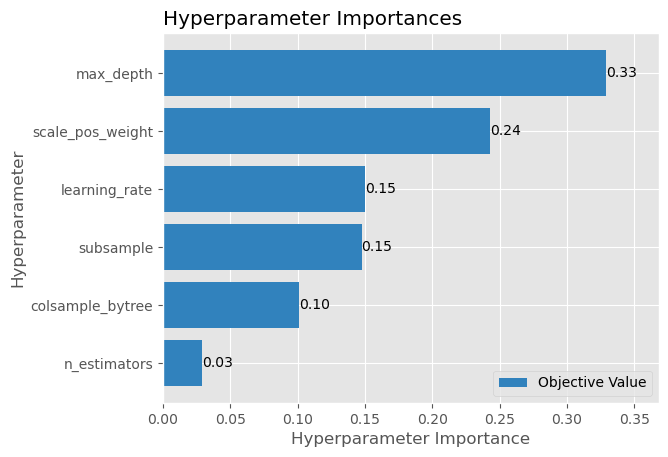

In [37]:
# Parameter importance
optuna.visualization.matplotlib.plot_param_importances(study);

C:\Users\Darach\AppData\Local\Temp\ipykernel_19820\2656397370.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study);


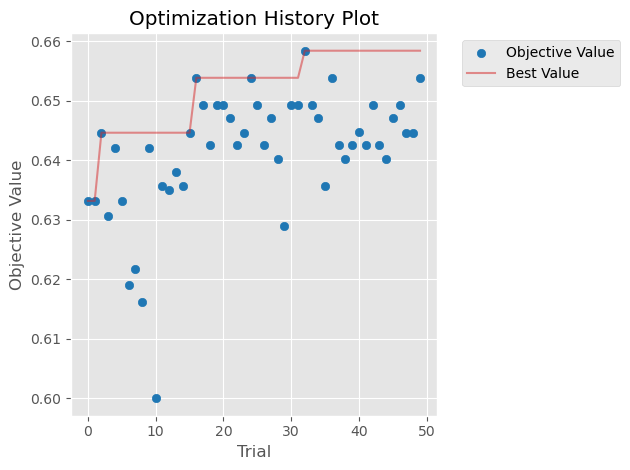

In [38]:
# Optimization history (how F1 improved over trials)
optuna.visualization.matplotlib.plot_optimization_history(study);

C:\Users\Darach\AppData\Local\Temp\ipykernel_19820\2949398106.py:2: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_parallel_coordinate(study)


<Axes: title={'center': 'Parallel Coordinate Plot'}>

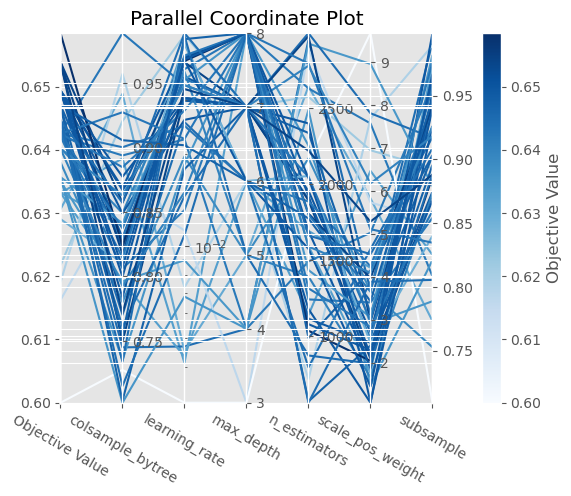

In [39]:
# Parallel coordinate plot (show trade-offs between params and F1)
optuna.visualization.matplotlib.plot_parallel_coordinate(study)

In [112]:
# # visualise (interactive)
# import plotly
# import optuna.visualization as vis

# # Parameter importance
# vis.plot_param_importances(study)

# # Optimization history (how F1 improved over trials)
# vis.plot_optimization_history(study)

# # Parallel coordinate plot (show trade-offs between params and F1)
# vis.plot_parallel_coordinate(study)

Now use best fitting parameters based on F1 to find best threshold value using precision-recall curves  
Set min recall quite high - 0.9 (we want to capture more biodiversity shocks at the risk of predicting more false positives)

In [107]:
from sklearn.base import clone
from sklearn.metrics import recall_score, precision_score, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

def find_best_threshold_rolling(
    df,
    features,
    target,
    pipeline,
    best_params,
    min_train_years=10,
    thresholds=np.linspace(0.1, 0.8, 50),
    min_recall=0.9,
    plot=True
):
    
    years = sorted(df['year_offset'].unique())
    splits = get_expanding_splits(years, min_train_years)
    
    all_y_true = []
    all_y_proba = []
    
    # Rolling validation
    for train_years, val_year in splits:
        train = df[df['year_offset'].isin(train_years)]
        val   = df[df['year_offset'] == val_year]
        
        X_train, y_train = train[features], train[target]
        X_val, y_val     = val[features], val[target]
        
        pipe = clone(pipeline)
        pipe.set_params(**best_params)
        
        pipe.fit(X_train, y_train)
        
        y_proba = pipe.predict_proba(X_val)[:, 1]
        
        all_y_true.extend(y_val)
        all_y_proba.extend(y_proba)
    
    y_true = np.array(all_y_true)
    y_proba = np.array(all_y_proba)
    
    # Threshold search
    results = []
    recalls = []
    precisions = []
    
    for t in thresholds:
        y_pred = (y_proba > t).astype(int)
        
        recall = recall_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        
        recalls.append(recall)
        precisions.append(precision)
        
        results.append({
            'threshold': t,
            'recall': recall,
            'precision': precision
        })
    
    # Apply recall constraint
    valid = [r for r in results if r['recall'] >= min_recall]

    if len(valid) == 0:
        print("⚠️ No threshold meets recall target — using max recall")
        best = max(results, key=lambda x: x['recall'])
    else:
        best = max(valid, key=lambda x: x['precision'])
    
    # Plotting
    if plot:
        # --- Precision-Recall curve ---
        pr_prec, pr_rec, _ = precision_recall_curve(y_true, y_proba)
        
        plt.figure()
        plt.plot(pr_rec, pr_prec)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall Curve (Rolling Validation)")
        plt.grid()
        plt.show()
        
        # --- Threshold vs metrics ---
        plt.figure()
        plt.plot(thresholds, recalls, label="Recall")
        plt.plot(thresholds, precisions, label="Precision")
        plt.axvline(best['threshold'], linestyle='--',
                    label=f"Chosen threshold ({best['threshold']:.2f})")
        
        plt.xlabel("Threshold")
        plt.ylabel("Score")
        plt.title("Threshold vs Recall / Precision")
        plt.legend()
        plt.grid()
        plt.show()
    
    return best, results

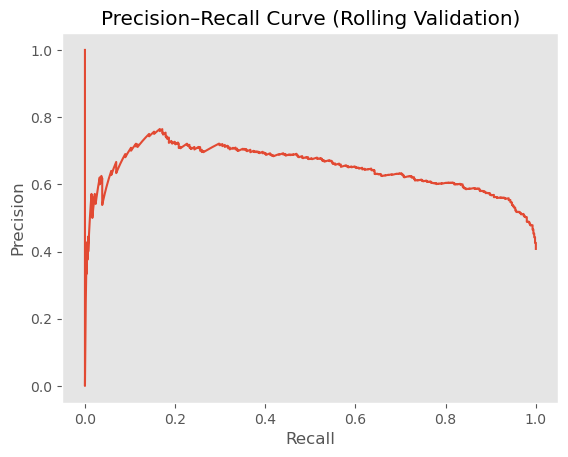

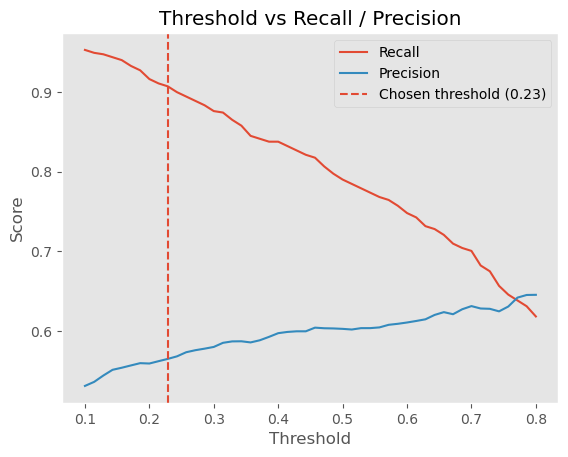

{'threshold': np.float64(0.2285714285714286), 'recall': 0.906934306569343, 'precision': 0.565415244596132}


In [73]:
best_params_prefixed = {f"model__{k}": v for k, v in best_trial.params.items()}

best_threshold_info, threshold_results = find_best_threshold_rolling(
    df=train_val,
    features=features,
    target='biodiversity_anomaly_sensitive',
    pipeline=full_pipeline_xgb,
    best_params=best_params_prefixed,
    min_recall=0.9,
    plot=True
)

print(best_threshold_info)

In [74]:
best_threshold_info['threshold']

np.float64(0.2285714285714286)

Use best parameters for training on full training data

In [75]:
best_params = {f"model__{k}": v for k, v in best_trial.params.items()}
best_threshold = best_threshold_info['threshold']

# Set these in your pipeline
full_pipeline_xgb.set_params(**best_params)

# Fit the pipeline on full training data
full_pipeline_xgb.fit(X_trainval, y_trainval)

# Predict probabilities on test set
y_proba = full_pipeline_xgb.predict_proba(X_test)[:, 1]
y_pred = (y_proba > best_threshold).astype(int)

# Evaluate
from sklearn.metrics import f1_score, accuracy_score
print("F1 on test:", f1_score(y_test, y_pred, average='macro'))

F1 on test: 0.8354716621837137


---
Experiment - can we get better train-validation f1 with reduced feature set?

In [123]:
reduced_cols = ['state', 'year_offset', 'month_sin', 'month_cos',
 'n_hot_days_lag1', 'n_hot_days_roll3',
 'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
 'temp_anom_z_lag1', 'temp_anom_z_roll3',
 'precip_anom_z_lag1', 'precip_anom_z_roll3',
 'drought_index_lag1','drought_index_roll3', 
 'log_n_obs', 'biodiversity_anomaly_sensitive']

trainval_reduced = train_val[reduced_cols].copy()
trainval_reduced.columns

Index(['state', 'year_offset', 'month_sin', 'month_cos', 'n_hot_days_lag1',
       'n_hot_days_roll3', 'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
       'temp_anom_z_lag1', 'temp_anom_z_roll3', 'precip_anom_z_lag1',
       'precip_anom_z_roll3', 'drought_index_lag1', 'drought_index_roll3',
       'log_n_obs', 'biodiversity_anomaly_sensitive'],
      dtype='object')

In [124]:
num_features_reduced = [c for c in num_features if c in reduced_cols]
num_features_reduced

['year_offset',
 'n_hot_days_lag1',
 'n_hot_days_roll3',
 'heavy_rain_days_lag1',
 'heavy_rain_days_roll3',
 'temp_anom_z_lag1',
 'temp_anom_z_roll3',
 'precip_anom_z_lag1',
 'precip_anom_z_roll3',
 'drought_index_lag1',
 'drought_index_roll3',
 'log_n_obs']

In [125]:
# Create reduced-features pipeline

preprocessor_noscale_reduced = ColumnTransformer(    transformers=[
        ('cat', oh_pipe, cat_features),
        ('num', 'passthrough', num_features_reduced),
        ('cyc', 'passthrough', cyc_features)
    ])


# Rebuild your pipeline with the updated preprocessor

full_pipeline_xgb_reduced = Pipeline([
    ('pre', preprocessor_noscale_reduced),
    ('model', XGBClassifier())
])

In [126]:
features_reduced = ['state', 'year_offset', 'month_sin', 'month_cos',
    'n_hot_days_lag1', 'n_hot_days_roll3',
    'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
    'temp_anom_z_lag1', 'temp_anom_z_roll3',
    'precip_anom_z_lag1', 'precip_anom_z_roll3',
    'drought_index_lag1', 'drought_index_roll3', 
    'log_n_obs']

study_reduced, results_df_reduced = optuna_rolling_search(
    df=trainval_reduced,
    features=features_reduced,
    target='biodiversity_anomaly_sensitive',
    pipeline=full_pipeline_xgb_reduced,
    param_space_fn=xgb_param_space,
    n_trials=50,
    use_early_stopping=False
)

[I 2026-04-14 12:17:56,913] A new study created in memory with name: no-name-16bfb2cb-0a30-4080-91fc-e55a40c9aa7d
[I 2026-04-14 12:17:57,775] Trial 0 finished with value: 0.6118637419666294 and parameters: {'n_estimators': 768, 'max_depth': 7, 'learning_rate': 0.008395555486297824, 'subsample': 0.8608560912750127, 'colsample_bytree': 0.8895695625775514, 'scale_pos_weight': 5.2844288470449845}. Best is trial 0 with value: 0.6118637419666294.
[I 2026-04-14 12:17:58,870] Trial 1 finished with value: 0.6129032258064516 and parameters: {'n_estimators': 1728, 'max_depth': 8, 'learning_rate': 0.04923939322738431, 'subsample': 0.848825513693929, 'colsample_bytree': 0.7362437137067755, 'scale_pos_weight': 6.249961210298341}. Best is trial 1 with value: 0.6129032258064516.
[I 2026-04-14 12:18:00,064] Trial 2 finished with value: 0.6261570260312135 and parameters: {'n_estimators': 2538, 'max_depth': 4, 'learning_rate': 0.005573144231176924, 'subsample': 0.8288557293564863, 'colsample_bytree': 0.7

In [127]:
# Sort by F1
results_df_reduced.sort_values('mean_f1', ascending=False).head(10)

,params,mean_f1
27,"{'n_estimators': 1991, 'max_depth': 5, 'learni...",0.658174
45,"{'n_estimators': 1331, 'max_depth': 4, 'learni...",0.653890
14,"{'n_estimators': 2003, 'max_depth': 7, 'learni...",0.651522
43,"{'n_estimators': 1660, 'max_depth': 4, 'learni...",0.649346
44,"{'n_estimators': 1764, 'max_depth': 4, 'learni...",0.647059
17,"{'n_estimators': 2036, 'max_depth': 5, 'learni...",0.647059
23,"{'n_estimators': 2290, 'max_depth': 5, 'learni...",0.644810
41,"{'n_estimators': 2118, 'max_depth': 4, 'learni...",0.644444
42,"{'n_estimators': 2360, 'max_depth': 3, 'learni...",0.642543
33,"{'n_estimators': 1995, 'max_depth': 4, 'learni...",0.642416


In [128]:
# Best trial according to Optuna
best_trial_reduced = study_reduced.best_trial

print("Best F1:", best_trial_reduced.value)
# print("Best threshold_f1:", best_trial_reduced.user_attrs.get('best_threshold_f1', None))
# print("Best threshold_recall:", best_trial_reduced.user_attrs.get('best_threshold_recall', None))
print("Best parameters:")
for key, value in best_trial_reduced.params.items():
    print(f"  {key}: {value}")

Best F1: 0.6581735399702303
Best parameters:
  n_estimators: 1991
  max_depth: 5
  learning_rate: 0.023705264277402622
  subsample: 0.909385293401718
  colsample_bytree: 0.9555075862291228
  scale_pos_weight: 1.0025622803117704


Search for best threshold with best fitting parameters, based on precision-recall curve

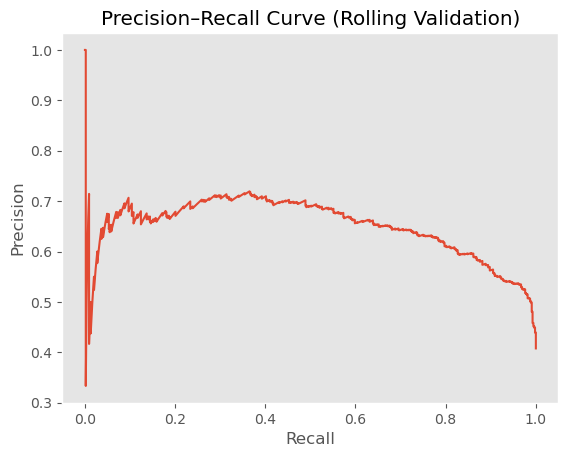

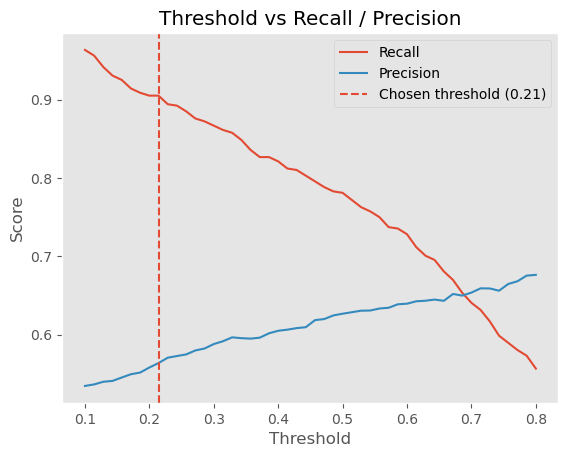

{'threshold': np.float64(0.2142857142857143), 'recall': 0.9051094890510949, 'precision': 0.5636363636363636}


In [129]:
best_params_reduced_prefixed = {f"model__{k}": v for k, v in best_trial_reduced.params.items()}

best_threshold_info, threshold_results = find_best_threshold_rolling(
    df=train_val,
    features=features_reduced,
    target='biodiversity_anomaly_sensitive',
    pipeline=full_pipeline_xgb_reduced,
    best_params=best_params_reduced_prefixed,
    min_recall=0.9,
    plot=True
)

print(best_threshold_info)

Use best parameters for training on full training data with best threshold

In [130]:
best_params_reduced = best_trial_reduced.params
best_params_prefixed = {f"model__{k}": v for k, v in best_params_reduced.items()}
#best_threshold_reduced = best_trial_reduced.user_attrs['best_threshold_f1']
#best_threshold_recall = best_trial_reduced.user_attrs['best_threshold_recall']
threshold = best_threshold_info['threshold']

# Set these in your pipeline
full_pipeline_xgb_reduced.set_params(**best_params_prefixed)

# Fit the pipeline on full training data
X_trainval_reduced = X_trainval[features_reduced]
full_pipeline_xgb_reduced.fit(X_trainval_reduced, y_trainval)

# Predict probabilities on test set
X_test_reduced = X_test[features_reduced]
y_proba_reduced = full_pipeline_xgb_reduced.predict_proba(X_test_reduced)[:, 1]
y_pred_reduced = (y_proba_reduced > threshold).astype(int)

# Evaluate
from sklearn.metrics import f1_score, accuracy_score
print("F1 on test:", f1_score(y_test, y_pred_reduced, average='macro'))

F1 on test: 0.8410924891371818


Nice! F1 value of 0.84 on test set

Evaluate with a confusion matrix

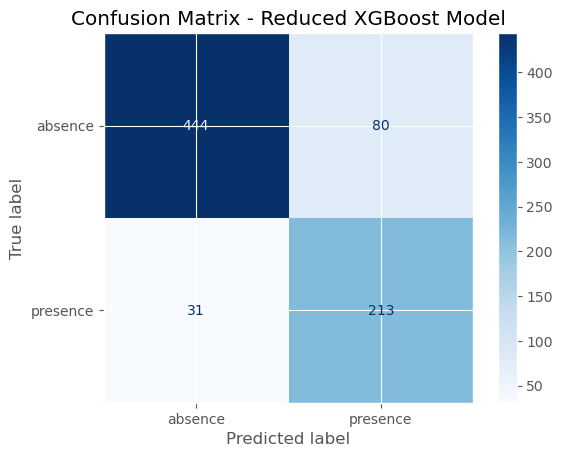

In [131]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_reduced)

# Create display
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['absence', 'presence'])  # adjust labels as needed
disp.plot(cmap='Blues')  # you can change color map

# Optionally add titles
import matplotlib.pyplot as plt
plt.title("Confusion Matrix - Reduced XGBoost Model")
plt.show()

---
Train production model using all data (train and test together) with best params

In [132]:
# clone the pipeline as a production model
pipeline_production = clone(full_pipeline_xgb_reduced)
pipeline_production.set_params(**best_params_prefixed)

# Fit the production pipeline on full data
X_full_reduced = df[features_reduced].copy()
y_full = df['biodiversity_anomaly_sensitive']
pipeline_production.fit(X_full_reduced, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [133]:
# sanity check
y_proba = pipeline_production.predict_proba(X_full_reduced)[:,1]
threshold = best_threshold_info['threshold']
y_pred = (y_proba > threshold).astype(int)

print(f1_score(y_full, y_pred))

0.9660762533773641


save evaluation model and production model

In [134]:
import joblib

joblib.dump({
    "model": full_pipeline_xgb_reduced,
    "threshold": best_threshold_info['threshold'],
    "features": features_reduced
}, "../models/evaluation_model.pkl")

joblib.dump({
    "model": pipeline_production,
    "threshold": best_threshold_info['threshold'],
    "features": features_reduced
}, "../models/production_model.pkl")

['../models/production_model.pkl']

---
---
Use rolling validation to get mean f1 to report for each time-aware CV fold

Rolling expanding window function (using TimeSeriesSplit)  
*note that TimeSeriesSplit doesn't necessarily split by year - see manual approach below*

In [ ]:
def rolling_gridsearch(df, features, target, model_pipeline, param_grid, start_years=5):
    """
    df: dataframe sorted by year
    features: list of features
    target: string target column
    model_pipeline: scikit-learn pipeline
    param_grid: dict for GridSearchCV
    start_years: number of initial years to train on
    """
    years = sorted(df['year_offset'].unique())
    results = []

    for i in range(start_years, len(years)):
        train_years = years[:i]
        val_year = years[i]
        
        train = df[df['year_offset'].isin(train_years)]
        val = df[df['year_offset'] == val_year]
        
        X_train, y_train = train[features], train[target]
        X_val, y_val = val[features], val[target]
        
        # Time-aware GridSearch
        tscv = TimeSeriesSplit(n_splits=len(train_years))  # inner CV
        
        grid = GridSearchCV(model_pipeline, param_grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
        grid.fit(X_train, y_train)
        
        y_pred = grid.predict(X_val)
        f1 = f1_score(y_val, y_pred, average = 'macro')
        
        results.append({
            'val_year': val_year,
            'f1': f1,
            'best_params': grid.best_params_
        })
    return pd.DataFrame(results).sort_values('f1', ascending=False)

Apply function

In [ ]:
# make sure X_trainval is sorted by year and month
X_trainval.head()

,state,year_offset,month_sin,month_cos,n_hot_days,n_hot_days_lag1,n_hot_days_roll3,heavy_rain_days,heavy_rain_days_lag1,heavy_rain_days_roll3,temp_anom_z,temp_anom_z_lag1,temp_anom_z_roll3,precip_anom_z,precip_anom_z_lag1,precip_anom_z_roll3,drought_index,drought_index_lag1,drought_index_roll3,log_n_obs
0,Baden-Württemberg,0,0.500000,8.660254e-01,0,0.0,0.0,4,1.0,1.333333,-0.460148,-0.493560,-0.782721,1.644347,-0.819545,0.099744,-2.104495,0.325985,-0.882465,2.550228
1,Baden-Württemberg,0,0.866025,5.000000e-01,0,0.0,0.0,2,4.0,2.000000,-0.086154,-0.460148,-0.223042,-0.698352,1.644347,0.216010,0.612199,-2.104495,-0.439053,2.437751
2,Baden-Württemberg,0,1.000000,6.123234e-17,0,0.0,0.0,0,2.0,2.333333,-0.810228,-0.086154,-0.346620,-0.761310,-0.698352,0.042150,-0.048919,0.612199,-0.388771,2.911158
3,Baden-Württemberg,0,0.866025,-5.000000e-01,0,0.0,0.0,1,0.0,2.000000,-0.321441,-0.810228,-0.452176,-0.667826,-0.761310,0.061562,0.346385,-0.048919,-0.513738,2.818226
4,Baden-Württemberg,0,0.500000,-8.660254e-01,0,0.0,0.0,0,1.0,1.000000,-1.195680,-0.321441,-0.405941,-0.566522,-0.667826,-0.709163,-0.629158,0.346385,0.303222,2.960946


In [ ]:
results_rf = rolling_gridsearch(df=train_val, 
                                features=num_features+cyc_features+cat_features,
                                target='biodiversity_anomaly_sensitive', 
                                model_pipeline=models['RandomForest']['pipeline'], 
                                param_grid=models['RandomForest']['param_grid'])
print(results_rf)

    val_year        f1                                        best_params
3          8  0.830303  {'model__class_weight': 'balanced', 'model__ma...
0          5  0.814882  {'model__class_weight': 'balanced', 'model__ma...
4          9  0.784884  {'model__class_weight': 'balanced', 'model__ma...
2          7  0.733333  {'model__class_weight': 'balanced', 'model__ma...
1          6  0.712911  {'model__class_weight': 'balanced', 'model__ma...
9         14  0.697095  {'model__class_weight': 'balanced', 'model__ma...
10        15  0.689913  {'model__class_weight': 'balanced', 'model__ma...
11        16  0.679599  {'model__class_weight': None, 'model__max_dept...
5         10  0.649346  {'model__class_weight': None, 'model__max_dept...
6         11  0.605127  {'model__class_weight': 'balanced', 'model__ma...
7         12  0.547054  {'model__class_weight': 'balanced', 'model__ma...
8         13  0.542394  {'model__class_weight': 'balanced', 'model__ma...


In [ ]:
results_xgb = rolling_gridsearch(df=train_val, 
                                features=num_features+cyc_features+cat_features,
                                target='biodiversity_anomaly_sensitive', 
                                model_pipeline=models['XGBoost']['pipeline'], 
                                param_grid=models['XGBoost']['param_grid'])
print(results_xgb)

    val_year        f1                                        best_params
0          5  0.818135  {'model__colsample_bytree': 1.0, 'model__learn...
4          9  0.811257  {'model__colsample_bytree': 0.7, 'model__learn...
11        16  0.773772  {'model__colsample_bytree': 1.0, 'model__learn...
3          8  0.771325  {'model__colsample_bytree': 0.7, 'model__learn...
1          6  0.764853  {'model__colsample_bytree': 0.7, 'model__learn...
9         14  0.747757  {'model__colsample_bytree': 1.0, 'model__learn...
2          7  0.710769  {'model__colsample_bytree': 1.0, 'model__learn...
7         12  0.697884  {'model__colsample_bytree': 1.0, 'model__learn...
10        15  0.695804  {'model__colsample_bytree': 1.0, 'model__learn...
6         11  0.685315  {'model__colsample_bytree': 1.0, 'model__learn...
5         10  0.653591  {'model__colsample_bytree': 0.7, 'model__learn...
8         13  0.632867  {'model__colsample_bytree': 1.0, 'model__learn...


In [ ]:
results_knn = rolling_gridsearch(df=train_val, 
                                features=num_features+cyc_features+cat_features,
                                target='biodiversity_anomaly_sensitive', 
                                model_pipeline=models['KNN']['pipeline'], 
                                param_grid=models['KNN']['param_grid'])
print(results_knn)

    val_year        f1                                        best_params
0          5  0.819061  {'model__n_neighbors': 5, 'model__p': 2, 'mode...
3          8  0.705134  {'model__n_neighbors': 7, 'model__p': 1, 'mode...
4          9  0.683354  {'model__n_neighbors': 7, 'model__p': 1, 'mode...
2          7  0.656213  {'model__n_neighbors': 5, 'model__p': 2, 'mode...
10        15  0.626202  {'model__n_neighbors': 3, 'model__p': 2, 'mode...
9         14  0.618954  {'model__n_neighbors': 3, 'model__p': 1, 'mode...
1          6  0.609615  {'model__n_neighbors': 7, 'model__p': 1, 'mode...
5         10  0.594103  {'model__n_neighbors': 7, 'model__p': 1, 'mode...
6         11  0.593574  {'model__n_neighbors': 7, 'model__p': 1, 'mode...
11        16  0.580146  {'model__n_neighbors': 5, 'model__p': 1, 'mode...
8         13  0.564293  {'model__n_neighbors': 7, 'model__p': 1, 'mode...
7         12  0.494449  {'model__n_neighbors': 7, 'model__p': 1, 'mode...
